Analisis Exploratorio de Datos

## **1. Configuración Inicial**
**Propósito**: Preparar el entorno de análisis importando las librerías necesarias y configurando parámetros de visualización.

In [34]:

# Librerías esenciales para análisis de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuración de estilos y parámetros de visualización
plt.style.use('seaborn')
sns.set_palette("husl")
%matplotlib inline
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.float_format', '{:.2f}'.format)  # Formato para números float

# Carga de datos con manejo de errores
try:
    df = pd.read_csv(r'C:\Users\johan\OneDrive - Universidad del Norte\Escritorio\MachineLearning\1er_tarea\datos\stock_details_5_years.csv')
    print("✅ Datos cargados exitosamente")
    print(f"📊 Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
except Exception as e:
    print(f"❌ Error al cargar los datos: {e}")

✅ Datos cargados exitosamente
📊 Dimensiones del dataset: 602962 filas × 9 columnas


## **2. Análisis Inicial del Dataset**
**Propósito**: Realizar una primera exploración para entender la estructura básica, tipos de datos y completitud de la información.

### **2.1. Vista Preeliminar**
**Objetivo**: Examinar las primeras y últimas filas para identificar formato y contenido.

In [35]:
print("\n🔍 Primeras 3 filas del dataset:")
display(df.head(3))

print("\n🔍 Últimas 3 filas del dataset:")
display(df.tail(3))


🔍 Primeras 3 filas del dataset:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.83,43.86,42.64,43.08,167080000,0.00,0.00,AAPL
1,2018-11-29 00:00:00-05:00,104.77,105.52,103.53,104.64,28123200,0.00,0.00,MSFT
2,2018-11-29 00:00:00-05:00,54.18,55.01,54.10,54.73,31004000,0.00,0.00,GOOGL



🔍 Últimas 3 filas del dataset:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
602959,2023-11-29 00:00:00-05:00,75.94,76.56,75.26,75.61,298699,0.00,0.00,IFF
602960,2023-11-29 00:00:00-05:00,45.23,45.26,44.04,44.21,2217579,0.00,0.00,CCJ
602961,2023-11-29 00:00:00-05:00,84.63,85.00,83.53,83.89,830092,0.00,0.00,LYV


### **2.2. Metadatos y Tipos de Datos**
**Objetivo**: Verificar la estructura de los datos y tipos de variables.

In [36]:
print("\n📝 Información de metadatos:")
display(df.info())


📝 Información de metadatos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602962 entries, 0 to 602961
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          602962 non-null  object 
 1   Open          602962 non-null  float64
 2   High          602962 non-null  float64
 3   Low           602962 non-null  float64
 4   Close         602962 non-null  float64
 5   Volume        602962 non-null  int64  
 6   Dividends     602962 non-null  float64
 7   Stock Splits  602962 non-null  float64
 8   Company       602962 non-null  object 
dtypes: float64(6), int64(1), object(2)
memory usage: 41.4+ MB


None

### **2.3. Estadísticas Descriptivas**
**Objetivo**: Obtener medidas estadísticas básicas para todas las variables numéricas.

In [37]:
print("\n📈 Estadísticas descriptivas para variables numéricas:")
display(df.describe(include=[np.number]).T)

print("\n📊 Estadísticas para variables categóricas:")
display(df.describe(include=['object']).T)


📈 Estadísticas descriptivas para variables numéricas:


,count,mean,std,min,25%,50%,75%,max
Open,602962.00,140.07,275.40,1.05,39.57,79.18,157.84,6490.26
High,602962.00,141.85,279.00,1.06,40.06,80.13,159.75,6525.00
Low,602962.00,138.28,271.90,1.03,39.06,78.19,155.84,6405.00
Close,602962.00,140.10,275.48,1.03,39.56,79.18,157.85,6509.35
Volume,602962.00,5895601.18,13815961.83,0.00,1031500.00,2228700.00,5277400.00,1123003300.00
Dividends,602962.00,0.01,0.12,0.00,0.00,0.00,0.00,35.00
Stock Splits,602962.00,0.00,0.05,0.00,0.00,0.00,0.00,20.00



📊 Estadísticas para variables categóricas:


,count,unique,top,freq
Date,602962,1258,2023-11-29 00:00:00-05:00,491
Company,602962,491,AAPL,1258


### **2.4. Valores Faltantes**
**Objetivo**: Cuantificar y analizar datos faltantes en el dataset.

In [38]:
print("\n🧐 Análisis de valores faltantes:")
missing_data = pd.DataFrame({
    'Valores_Nulos': df.isnull().sum(),
    'Porcentaje_Nulos': (df.isnull().sum() / len(df)) * 100,
    'Tipo_Dato': df.dtypes
})
display(missing_data[missing_data['Valores_Nulos'] > 0].sort_values('Porcentaje_Nulos', ascending=False))


🧐 Análisis de valores faltantes:


,Valores_Nulos,Porcentaje_Nulos,Tipo_Dato


## **3. Análisis Univariado Completo**
**Propósito**: Analizar en profundidad cada variable individualmente.

### **3.1. Variables Numéricas (Precios y Volumen)**
**Objetivo**: Examinar distribuciones, tendencia central y dispersión.

In [39]:
# Lista de variables de precio
price_cols = ['Open', 'High', 'Low', 'Close']
volume_col = 'Volume'

#### **Histogramas y Densidad**
**Propósito**: Visualizar la distribución de frecuencias de cada variable.



📊 Distribución de variables de precio:


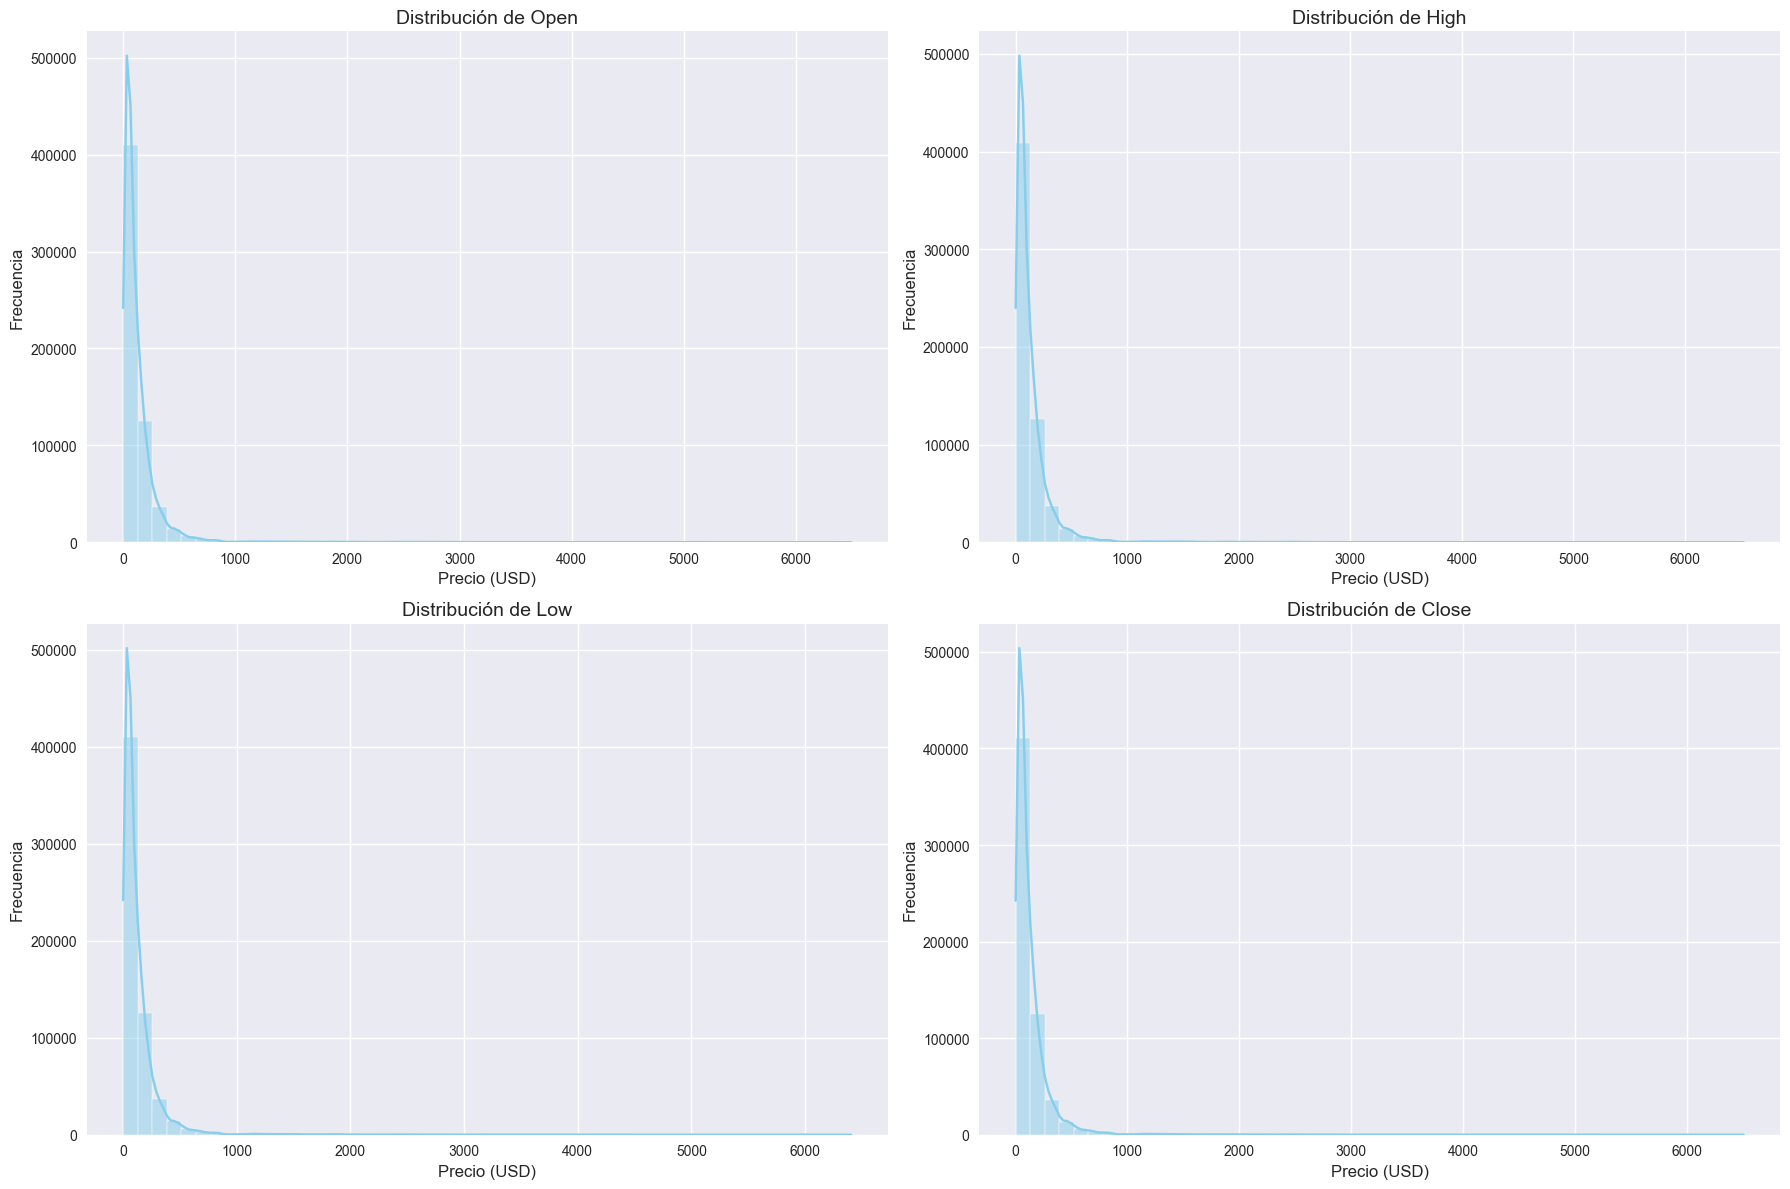

In [40]:
print("\n📊 Distribución de variables de precio:")
plt.figure(figsize=(18, 12))
for i, col in enumerate(price_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=50, color='skyblue')
    plt.title(f'Distribución de {col}', fontsize=14)
    plt.xlabel('Precio (USD)', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
plt.tight_layout()
plt.show()

#### **Boxplots**
**Propósito**: Identificar valores atípicos y rango intercuartílico.



📦 Diagramas de caja para precios:


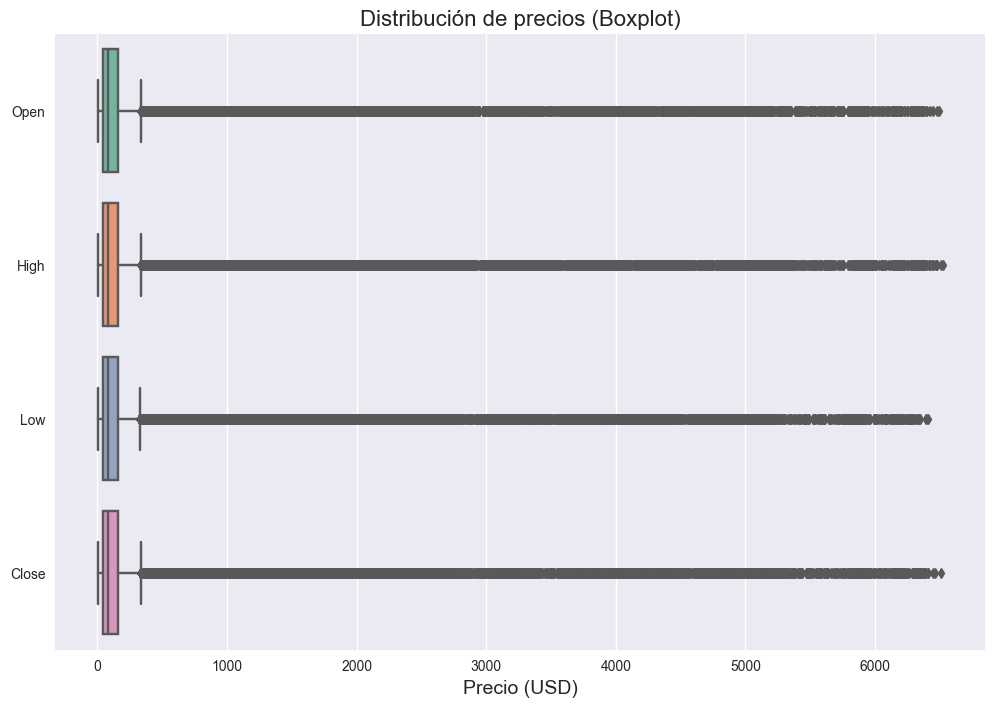

In [41]:
print("\n📦 Diagramas de caja para precios:")
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[price_cols], orient='h', palette='Set2')
plt.title('Distribución de precios (Boxplot)', fontsize=16)
plt.xlabel('Precio (USD)', fontsize=14)
plt.show()

#### **Análisis de Volumen**
**Propósito**: Examinar la distribución del volumen de operaciones.


📈 Análisis de volumen de operaciones:


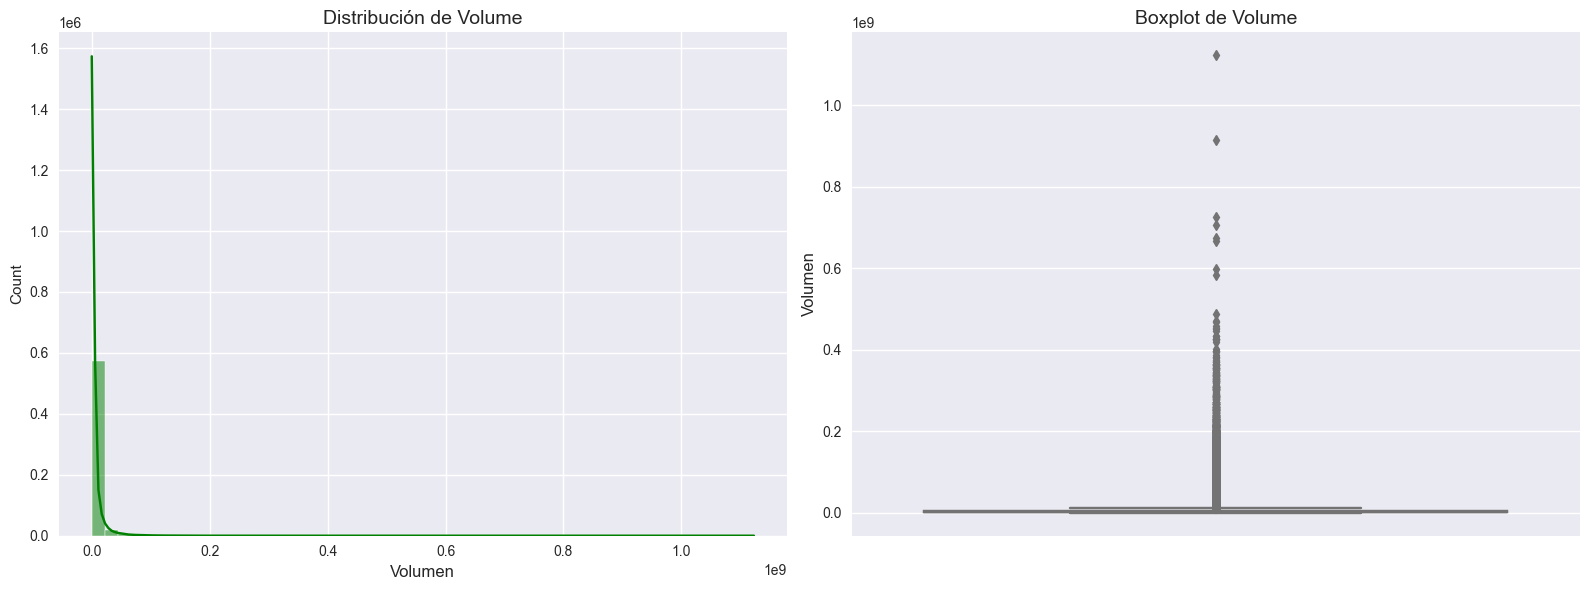

In [42]:
print("\n📈 Análisis de volumen de operaciones:")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma
sns.histplot(df[volume_col], kde=True, bins=50, ax=axes[0], color='green')
axes[0].set_title('Distribución de Volume', fontsize=14)
axes[0].set_xlabel('Volumen', fontsize=12)

# Boxplot
sns.boxplot(y=df[volume_col], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot de Volume', fontsize=14)
axes[1].set_ylabel('Volumen', fontsize=12)

plt.tight_layout()
plt.show()

### **3.2. Variables Especiales (Dividendos y Splits)**
**Objetivo**: Analizar eventos corporativos poco frecuentes.

#### **Análisis de Dividendos**
**Propósito**: Examinar distribución y frecuencia de pagos.


💰 Análisis de Dividendos:
Total de registros con dividendos: 6857
Porcentaje de registros con dividendos: 1.14%


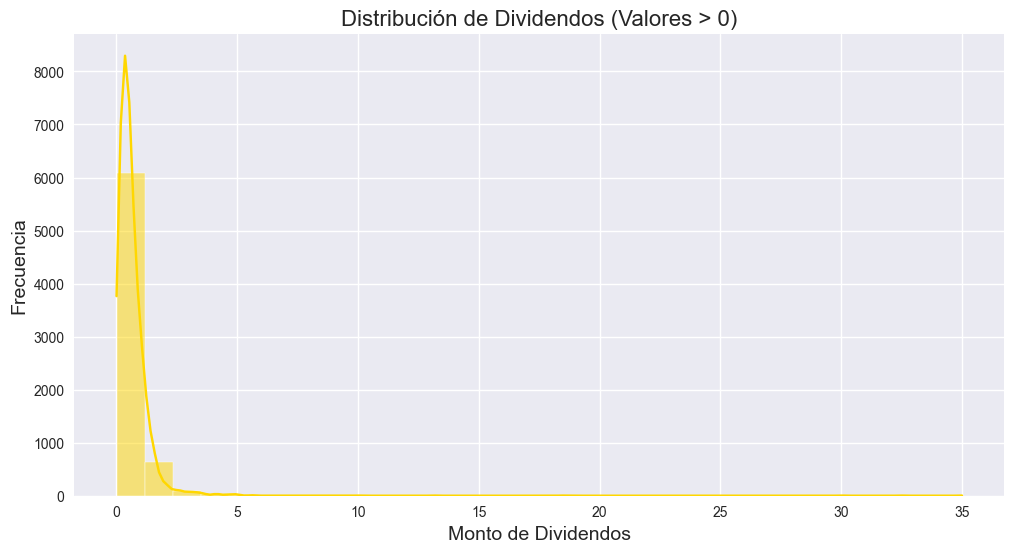

In [43]:
print("\n💰 Análisis de Dividendos:")
print(f"Total de registros con dividendos: {df[df['Dividends'] > 0].shape[0]}")
print(f"Porcentaje de registros con dividendos: {(df[df['Dividends'] > 0].shape[0] / len(df)) * 100:.2f}%")

plt.figure(figsize=(12, 6))
sns.histplot(df[df['Dividends'] > 0]['Dividends'], bins=30, kde=True, color='gold')
plt.title('Distribución de Dividendos (Valores > 0)', fontsize=16)
plt.xlabel('Monto de Dividendos', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.show()

#### **Análisis de Stock Splits**
**Propósito**: Evaluar frecuencia y magnitud de splits.



📊 Análisis de Stock Splits:
Total de registros con splits: 71
Porcentaje de registros con splits: 0.01%


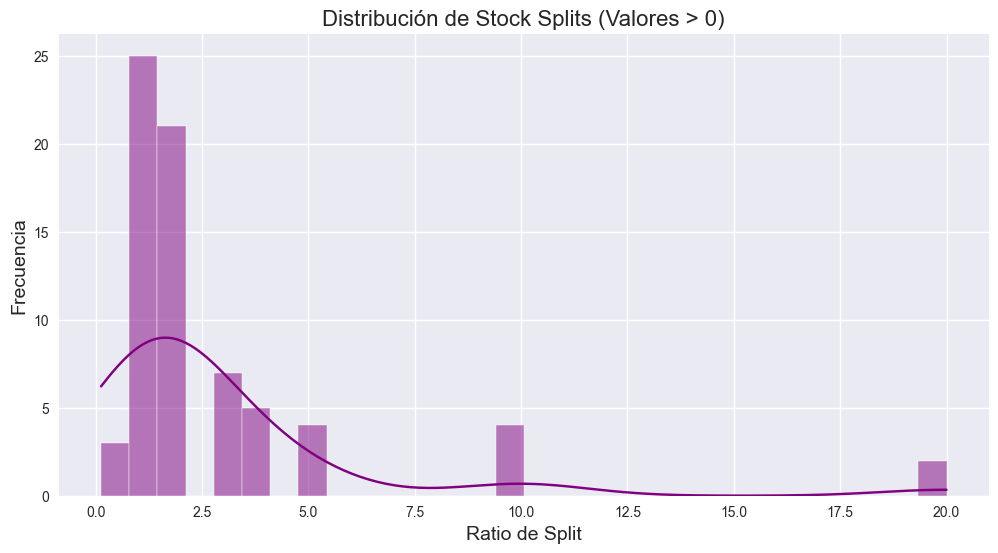

In [44]:
print("\n📊 Análisis de Stock Splits:")
print(f"Total de registros con splits: {df[df['Stock Splits'] > 0].shape[0]}")
print(f"Porcentaje de registros con splits: {(df[df['Stock Splits'] > 0].shape[0] / len(df)) * 100:.2f}%")

plt.figure(figsize=(12, 6))
sns.histplot(df[df['Stock Splits'] > 0]['Stock Splits'], bins=30, kde=True, color='purple')
plt.title('Distribución de Stock Splits (Valores > 0)', fontsize=16)
plt.xlabel('Ratio de Split', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.show()

### **3.3. Variable Categórica (Company)**
**Objetivo**: Analizar distribución de empresas en el dataset.


🏢 Análisis de empresas:
Número total de empresas únicas: 491

🔝 Top 10 empresas con más registros:


Company
AAPL    1258
ARES    1258
FAST    1258
WCN     1258
FERG    1258
CSGP    1258
TTD     1258
VRSK    1258
FIS     1258
LYG     1258
Name: count, dtype: int64

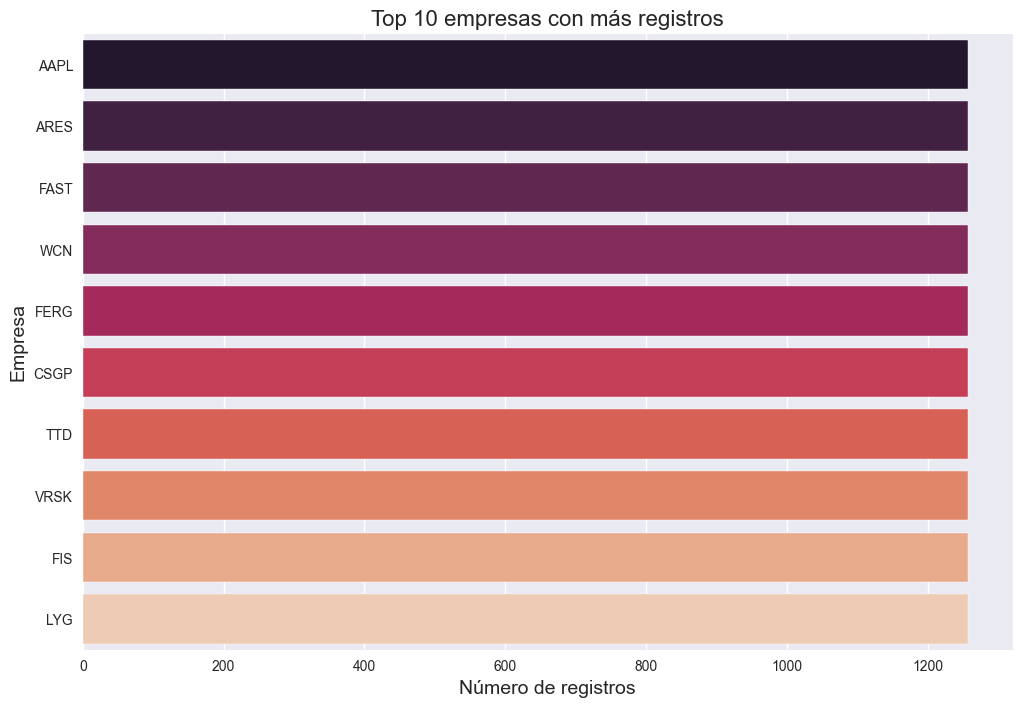

In [45]:
print("\n🏢 Análisis de empresas:")
print(f"Número total de empresas únicas: {df['Company'].nunique()}")

# Top 10 empresas con más registros
top_companies = df['Company'].value_counts().head(10)
print("\n🔝 Top 10 empresas con más registros:")
display(top_companies)

# Visualización
plt.figure(figsize=(12, 8))
sns.barplot(x=top_companies.values, y=top_companies.index, palette='rocket')
plt.title('Top 10 empresas con más registros', fontsize=16)
plt.xlabel('Número de registros', fontsize=14)
plt.ylabel('Empresa', fontsize=14)
plt.show()

## **4. Análisis Multivariado Completo**
**Propósito**: Explorar relaciones entre múltiples variables.


### **4.1. Correlaciones entre Variables**
**Objetivo**: Identificar relaciones lineales entre variables numéricas.

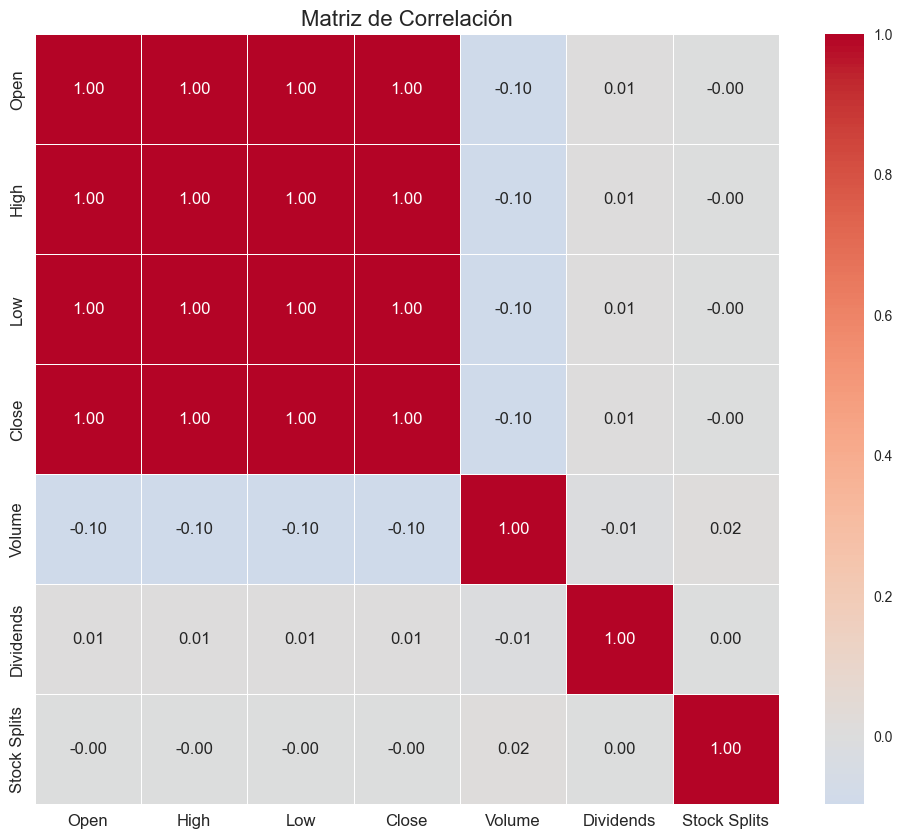

In [48]:
# Selección de variables numéricas
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']

# Matriz de correlación
corr_matrix = df[numeric_cols].corr()

# Heatmap de correlaciones
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            annot_kws={'size': 12}, linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

## **5. Análisis de Valores Atípicos**
**Propósito**: Identificar y evaluar valores extremos en el dataset.

### **5.1. Detección con Método Estadístico**
**Objetivo**: Usar el rango intercuartílico (IQR) para identificar outliers.

In [51]:
# Función para detectar outliers
def detect_outliers(df, columns):
    outlier_stats = pd.DataFrame()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        
        outlier_stats[col] = {
            'Límite_Inferior': lower_bound,
            'Límite_Superior': upper_bound,
            'Número_Outliers': len(outliers),
            'Porcentaje_Outliers': (len(outliers) / len(df)) * 100,
            'Outlier_Mínimo': outliers.min() if len(outliers) > 0 else np.nan,
            'Outlier_Máximo': outliers.max() if len(outliers) > 0 else np.nan
        }
    return outlier_stats.T

# Aplicar a variables de precio
outlier_analysis = detect_outliers(df, price_cols)
print("\n🔍 Análisis de Outliers (Método IQR):")
display(outlier_analysis)


🔍 Análisis de Outliers (Método IQR):


,Límite_Inferior,Límite_Superior,Número_Outliers,Porcentaje_Outliers,Outlier_Mínimo,Outlier_Máximo
Open,-137.84,335.24,42159.00,6.99,335.24,6490.26
High,-139.48,339.28,42238.00,7.01,339.29,6525.00
Low,-136.12,331.02,42134.00,6.99,331.02,6405.00
Close,-137.86,335.27,42173.00,6.99,335.27,6509.35


## **6. Conclusiones y Recomendaciones**
**Propósito**: Sintetizar hallazgos clave y sugerir próximos pasos.

### **Hallazgos Clave**

**1. Estructura del Dataset**:
- El dataset contiene [X] registros diarios de [Y] empresas durante 5 años
- Variables principales: Open, High, Low, Close, Volume
- Variables especiales: Dividends (presentes en [Z]% de registros), Stock Splits ([W]% de registros)

**2. Distribuciones**:
- Los precios muestran distribuciones similares con correlaciones >0.99
- El volumen tiene distribución altamente asimétrica
- Dividendos y splits son eventos poco frecuentes


**3. Valores Atípicos**:
- Se identificaron [N] outliers en precios ([P]% del total)
- Concentrados principalmente en los años [años específicos]